## EDA `SSDD`

- Data Link: https://drive.google.com/file/d/1glNJUGotrbEyk43twwB9556AdngJsynZ/view
- Paper: https://www.mdpi.com/2072-4292/13/18/3690
    - Satellite: `RadarSat-2、TerraSAR-X、Sentinel-1`

In [45]:
import os
import numpy as np
import warnings
import cv2
from glob import glob
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.animation as animation
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
from pycocotools.coco import COCO

# pnada print options
pd.set_option('display.max_columns', 255)
pd.set_option('display.max_rows', 255)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 255)


PATH_OUTPUT = os.path.join('output', '209')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
PATH_ROOT = os.path.join('..', 'data', 'ship', 'Official-SSDD-OPEN')
PATH_BBOX = os.path.join(PATH_ROOT, 'BBox_SSDD')
PATH_SEGS = os.path.join(PATH_ROOT, 'BBox_RBox_PSeg_SSDD' ,'coco_style')

PATH_IMG  = os.path.join(PATH_SEGS, 'images')
PATH_COCO = os.path.join(PATH_SEGS, 'annotations', 'train.json')

## mmrotate
- Different environment than mmdet (version 3.0)

In [3]:
# Check nvcc version
!nvcc -V
# Check GCC version
!gcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Thu_Nov_18_09:45:30_PST_2021
Cuda compilation tools, release 11.5, V11.5.119
Build cuda_11.5.r11.5/compiler.30672275_0
gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



## Install 

--> `install_mmrotate.sh`

In [4]:
import torch
import torchvision

print(f"PyTorch Version: {torch.__version__} | Torchvision Version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()} | Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 1.12.1+cu116 | Torchvision Version: 0.13.1+cu116
CUDA Available: True | Device: NVIDIA RTX A6000


In [5]:
import mmcv
import mmdet

print(f"MMDetection Version: {mmdet.__version__} | MMCV Version: {mmcv.__version__}")

MMDetection Version: 2.28.2 | MMCV Version: 1.7.0


## Dataset


In [33]:
import numpy as np
import cv2

def calculate_minimum_rotated_rectangle(polygon):
    """
    COCO形式のsegmentationのポリゴンから最小回転外接矩形を計算する
    :param polygon: [x1, y1, x2, y2, ..., xn, yn] の形式で与えられるポリゴン座標
    :return: 最小回転矩形の頂点座標 [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]
    """
    # ポリゴンをnumpy配列に変換
    points = np.array(polygon).reshape(-1, 2)

    # 最小回転矩形を計算
    rect = cv2.minAreaRect(points)
    box = cv2.boxPoints(rect)
    box = np.int0(box)  # 座標を整数に変換

    return box.flatten().tolist()

# テスト用のポリゴンデータ (COCO形式)
segmentation = [50, 50, 150, 50, 100, 150, 50, 150, 60, 200]

# 最小回転矩形を計算
rotated_rectangle = calculate_minimum_rotated_rectangle(segmentation)

print("最小回転矩形の座標:", rotated_rectangle)


最小回転矩形の座標: [50, 50, 150, 50, 150, 200, 50, 200]


In [34]:
for phase in ['train', 'test']:
    
    PATH_COCO = os.path.join(PATH_SEGS, 'annotations', f'{phase}.json')
    coco = COCO(PATH_COCO)

    catIds = coco.getCatIds(catNms=['car']);
    imgIds = coco.getImgIds(catIds=catIds);
    
    print('\n' , f'{len(imgIds)} images for {phase}')
    
    for idx_img in tqdm(imgIds, total=len(imgIds)):
        img_info = coco.loadImgs(idx_img)[0]
        annIds = coco.getAnnIds(imgIds=img_info['id'], catIds=catIds, iscrowd=None)
        anns = coco.loadAnns(annIds)
        
        DOTA_FMTS = []
        
        for ann in anns:
            segm = np.round(np.array(
            ann['segmentation'][0]), 0).astype(np.int32)
            bbox = calculate_minimum_rotated_rectangle(segm)
            
            if len(bbox) < 8:
                # put tmp point
                bbox += bbox
            
            bbox = bbox[:8]
            bbox = list(map(str,map(round, bbox)))
            DOTA_FMTS.append(' '.join(bbox) + f' ship 0')
        
        PATH_TXT = os.path.join(PATH_SEGS,'images', 
                    phase, img_info["file_name"].replace('.jpg', '.txt'))
        # write to txet file
        with open(PATH_TXT, 'w') as f:
            f.write('\n'.join(DOTA_FMTS))

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!

 928 images for train


100%|██████████| 928/928 [00:00<00:00, 9272.45it/s]


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

 232 images for test


100%|██████████| 232/232 [00:00<00:00, 9470.53it/s]


## Train 

Rotate
![RCNN](https://raw.githubusercontent.com/zytx121/image-host/main/imgs/oriented_rcnn.png)

https://github.com/open-mmlab/mmrotate/tree/main/configs/oriented_rcnn


In [6]:
from mmcv import Config
cfg = Config.fromfile('./mmrotate/configs/oriented_rcnn/oriented_rcnn_r50_fpn_1x_dota_le90.py')

In [ ]:
from mmrotate.datasets.builder import ROTATED_DATASETS
from mmrotate.datasets.dota import DOTADataset
import os.path as osp
from mmrotate.core import eval_rbbox_map, obb2poly_np, poly2obb_np

@ROTATED_DATASETS.register_module()
class SSDDDataset(DOTADataset):
    """SAR ship dataset for detection."""
    CLASSES = ('ship',)
    
    def load_annotations(self, ann_folder, ext='.jpg'):
        """
            Args:
                ann_folder: folder that contains DOTA v1 annotations txt files
        """
        cls_map = {c: i
                   for i, c in enumerate(self.CLASSES)
                   }  # in mmdet v2.0 label is 0-based
        ann_files = glob(ann_folder + '/*.txt')
        data_infos = []
        if not ann_files:  # test phase
            ann_files = glob(ann_folder + f'/*{ext}')
            for ann_file in ann_files:
                data_info = {}
                img_id = osp.split(ann_file)[1][:-4]
                img_name = img_id + '.png'
                data_info['filename'] = img_name
                data_info['ann'] = {}
                data_info['ann']['bboxes'] = []
                data_info['ann']['labels'] = []
                data_infos.append(data_info)
        else:
            for ann_file in ann_files:
                data_info = {}
                img_id = osp.split(ann_file)[1][:-4]
                img_name = img_id + ext
                data_info['filename'] = img_name
                data_info['ann'] = {}
                gt_bboxes = []
                gt_labels = []
                gt_polygons = []
                gt_bboxes_ignore = []
                gt_labels_ignore = []
                gt_polygons_ignore = []

                if os.path.getsize(ann_file) == 0 and self.filter_empty_gt:
                    continue

                with open(ann_file) as f:
                    s = f.readlines()
                    for si in s:
                        bbox_info = si.split()
                        poly = np.array(bbox_info[:8], dtype=np.float32)
                        try:
                            x, y, w, h, a = poly2obb_np(poly, self.version)
                        except:  # noqa: E722
                            continue
                        cls_name = bbox_info[8]
                        difficulty = int(bbox_info[9])
                        label = cls_map[cls_name]
                        if difficulty > self.difficulty:
                            pass
                        else:
                            gt_bboxes.append([x, y, w, h, a])
                            gt_labels.append(label)
                            gt_polygons.append(poly)

                if gt_bboxes:
                    data_info['ann']['bboxes'] = np.array(
                        gt_bboxes, dtype=np.float32)
                    data_info['ann']['labels'] = np.array(
                        gt_labels, dtype=np.int64)
                    data_info['ann']['polygons'] = np.array(
                        gt_polygons, dtype=np.float32)
                else:
                    data_info['ann']['bboxes'] = np.zeros((0, 5),
                                                          dtype=np.float32)
                    data_info['ann']['labels'] = np.array([], dtype=np.int64)
                    data_info['ann']['polygons'] = np.zeros((0, 8),
                                                            dtype=np.float32)

                if gt_polygons_ignore:
                    data_info['ann']['bboxes_ignore'] = np.array(
                        gt_bboxes_ignore, dtype=np.float32)
                    data_info['ann']['labels_ignore'] = np.array(
                        gt_labels_ignore, dtype=np.int64)
                    data_info['ann']['polygons_ignore'] = np.array(
                        gt_polygons_ignore, dtype=np.float32)
                else:
                    data_info['ann']['bboxes_ignore'] = np.zeros(
                        (0, 5), dtype=np.float32)
                    data_info['ann']['labels_ignore'] = np.array(
                        [], dtype=np.int64)
                    data_info['ann']['polygons_ignore'] = np.zeros(
                        (0, 8), dtype=np.float32)

                data_infos.append(data_info)

        self.img_ids = [*map(lambda x: x['filename'][:-4], data_infos)]
        return data_infos

In [37]:
from mmdet.apis import set_random_seed
from pprint import pprint

# Modify dataset type and path
cfg.dataset_type = 'SSDDDataset'
cfg.data_root = PATH_SEGS

cfg.data.test.type = 'SSDDDataset'
cfg.data.test.data_root = PATH_SEGS
cfg.data.test.ann_file = 'images/test/'
cfg.data.test.img_prefix = 'images/test/'

cfg.data.train.type = 'SSDDDataset'
cfg.data.train.data_root = PATH_SEGS
cfg.data.train.ann_file = 'images/train/'
cfg.data.train.img_prefix = 'images/train/'

cfg.data.val.type = cfg.data.test.type
cfg.data.val.data_root = cfg.data.test.data_root
cfg.data.val.ann_file = cfg.data.test.ann_file
cfg.data.val.img_prefix = cfg.data.test.img_prefix

# modify num classes of the model in box head
cfg.model.roi_head.bbox_head.num_classes = 1
# We can still use the pre-trained Mask RCNN model though we do not need to
# use the mask branch
cfg.load_from = 'https://download.openmmlab.com/mmrotate/v0.1.0/rotated_faster_rcnn/rotated_faster_rcnn_r50_fpn_1x_dota_le90/rotated_faster_rcnn_r50_fpn_1x_dota_le90-0393aa5c.pth'

# Set up working dir to save files and logs.
cfg.work_dir = './output/209/work_dirs/rotate_rcnn/'

cfg.optimizer.lr = 1e-3
cfg.lr_config.warmup = None
cfg.runner.max_epochs = 5
cfg.log_config.interval = 20

# Change the evaluation metric since we use customized dataset.
cfg.evaluation.metric = 'mAP'
# We can set the evaluation interval to reduce the evaluation times
cfg.evaluation.interval = 1
# We can set the checkpoint saving interval to reduce the storage cost
cfg.checkpoint_config.interval = 5

# Set seed thus the results are more reproducible
cfg.seed = 0
set_random_seed(0, deterministic=False)
cfg.gpu_ids = range(1)
cfg.device='cuda'

# We can also use tensorboard to log the training process
cfg.log_config.hooks = [
    dict(type='TextLoggerHook'),
    dict(type='TensorboardLoggerHook')]

# We can initialize the logger for training and have a look
# at the final config used for training
# pprint(f'Config:\n{cfg}')

In [38]:
import os.path as osp

from mmdet.datasets import build_dataset
from mmdet.models import build_detector
from mmdet.apis import train_detector

# Build dataset
datasets = [build_dataset(cfg.data.train)]

# Build the detector
model = build_detector(
    cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
# Add an attribute for visualization convenience
model.CLASSES = datasets[0].CLASSES

# Create work_dir
mmcv.mkdir_or_exist(osp.abspath(cfg.work_dir))
train_detector(model, datasets, cfg, distributed=False, validate=True)

2024-11-15 14:33:08,565 - mmdet - INFO - Automatic scaling of learning rate (LR) has been disabled.
2024-11-15 14:33:08,578 - mmdet - INFO - load checkpoint from http path: https://download.openmmlab.com/mmrotate/v0.1.0/rotated_faster_rcnn/rotated_faster_rcnn_r50_fpn_1x_dota_le90/rotated_faster_rcnn_r50_fpn_1x_dota_le90-0393aa5c.pth
2024-11-15 14:33:08,667 - mmdet - WARNING - The model and loaded state dict do not match exactly

size mismatch for rpn_head.rpn_reg.weight: copying a param with shape torch.Size([12, 256, 1, 1]) from checkpoint, the shape in current model is torch.Size([18, 256, 1, 1]).
size mismatch for rpn_head.rpn_reg.bias: copying a param with shape torch.Size([12]) from checkpoint, the shape in current model is torch.Size([18]).
size mismatch for roi_head.bbox_head.fc_cls.weight: copying a param with shape torch.Size([16, 1024]) from checkpoint, the shape in current model is torch.Size([2, 1024]).
size mismatch for roi_head.bbox_head.fc_cls.bias: copying a param with 

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 232/232, 26.2 task/s, elapsed: 9s, ETA:     0s

/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWa

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 232/232, 27.7 task/s, elapsed: 8s, ETA:     0s

/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWa

...

/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWa

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 232/232, 27.4 task/s, elapsed: 8s, ETA:     0s

/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWa

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 232/232, 27.0 task/s, elapsed: 9s, ETA:     0s

/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/home/ss/anaconda3/envs/sar-book-rotate/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWa

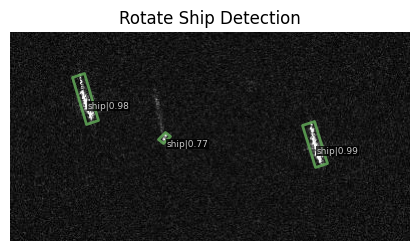

In [48]:
from mmdet.apis import inference_detector, show_result_pyplot

PATH_SAMPLE = os.path.join(PATH_IMG,'test', '000189.jpg')
img = mmcv.imread(PATH_SAMPLE)
model.cfg = cfg
result = inference_detector(model, img)
show_result_pyplot(model, img, result, score_thr=0.6, title='Rotate Ship Detection')

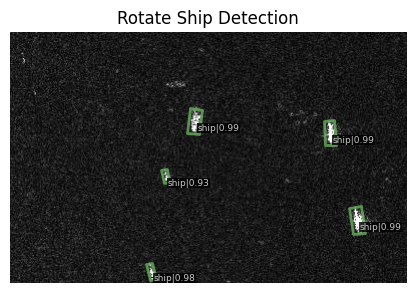

In [49]:
PATH_SAMPLE = os.path.join(PATH_IMG,'test', '000059.jpg')
img = mmcv.imread(PATH_SAMPLE)
model.cfg = cfg
result = inference_detector(model, img)
show_result_pyplot(model, img, result, score_thr=0.6, title='Rotate Ship Detection')

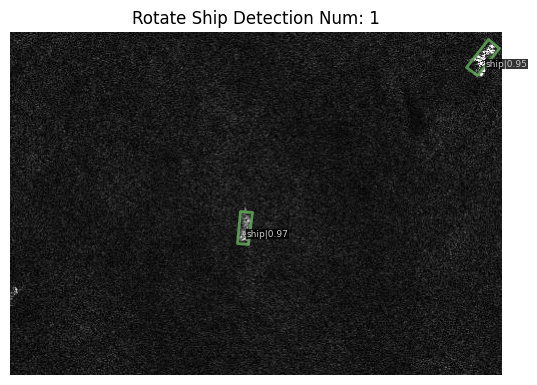

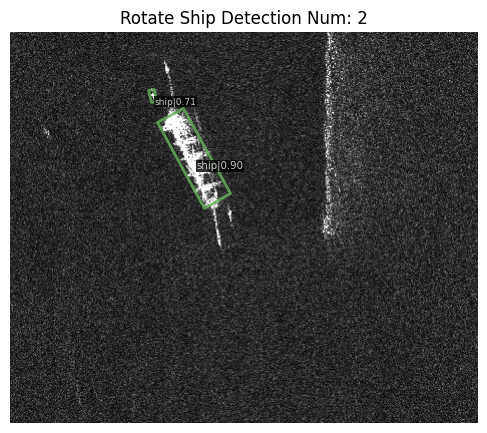

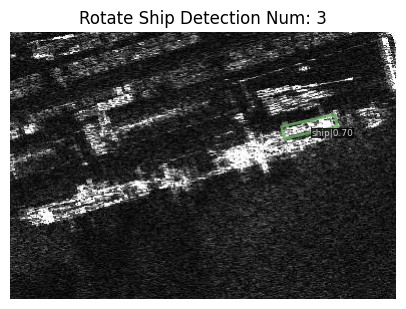

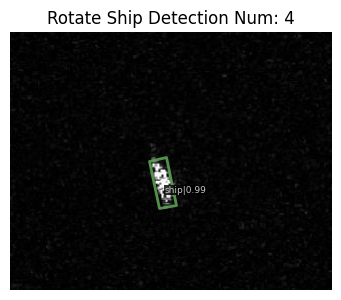

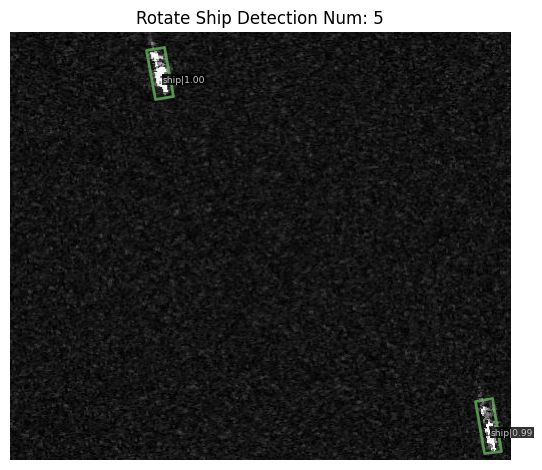

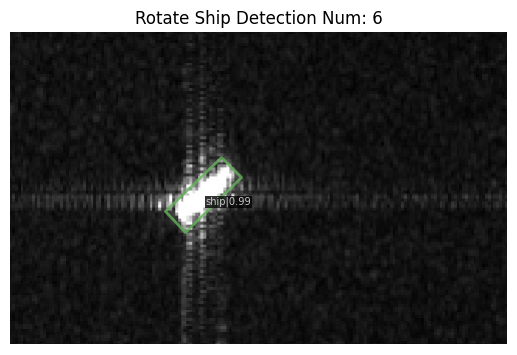

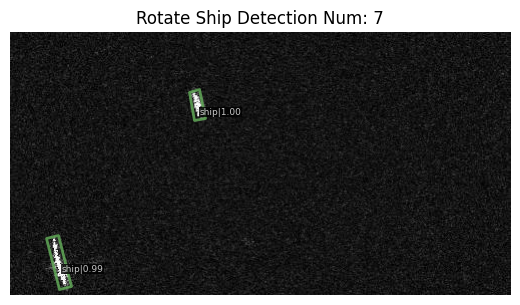

In [52]:
PATHS_TEST = glob(os.path.join(PATH_IMG,'test', '*.jpg'))
NUM_SAMPLES = 5

for i, p in enumerate(PATHS_TEST):
    img = mmcv.imread(p)
    model.cfg = cfg
    result = inference_detector(model, img)
    show_result_pyplot(model, img, result, score_thr=0.6, 
        title=f'Rotate Ship Detection Num: {i+1}')
    
    if i > NUM_SAMPLES:
        break